In [ ]:
!unzip /content/real.zip

Archive:  /content/real.zip
   creating: Augmented IQ-OTHNCCD lung cancer dataset/
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/.DS_Store  
   creating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (1).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (10).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (100).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (101).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (102).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (103).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (104).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Benign cases/Bengin case (105).jpg  
  inflating: Augmented IQ-OTHNCCD lung cancer dataset/Beni

Found folders: ['Benign', 'Malignant']
Total images: 2401
Train: 1680 | Validation: 721
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}

--- Training classifier head (frozen base) ---
Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.7376 - loss: 0.5064 - recall: 0.7508 - val_accuracy: 0.9445 - val_loss: 0.1719 - val_recall: 0.9418 - learning_rate: 0.0010
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9554 - loss: 0.1542 - recall: 0.9442 - val_accuracy: 0.9681 - val_loss: 0.1076 - val_recall: 0.9501 - learning_rate: 0.0010
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9631 - loss: 0.1130 - recall: 0.9486 - val_accuracy: 0.9723 - val_loss: 0.0847 - val_recall: 0.9501 - learning_rate: 0.0010
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9813 - loss: 0.0734 - recall: 0.9775 - val_accuracy: 0.9723 - val_loss: 0.0772 - val_recall: 0.9474 - learning_rate: 0.0010
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms


✅ Final Validation Accuracy: 99.31% | Recall: 98.89%

✅ Model saved as mobilenetv2_lung_model.h5

📤 Please upload a lung CT image for classification...


Saving auto_contrast (2).jpg to auto_contrast (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


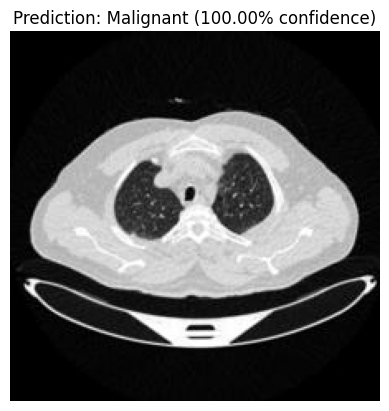


🩻 Image: auto_contrast (2).jpg
➡ Prediction: Malignant
➡ Confidence: 100.00%


In [ ]:
import os, numpy as np, tensorflow as tf
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils import class_weight

# ---------------- CONFIG ----------------
DATA_DIR = "/content/real"   # must contain "Benign/" and "Malignant/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_HEAD = 5
EPOCHS_FINE = 5
UNFREEZE_LAYERS = 30
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
# ----------------------------------------

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -------- 1) Load & Stratified Split (70/30) ----------
# -------- 1) Load & Stratified Split (70/30) ----------
data_dir = Path(DATA_DIR)
classes = [c for c in sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
           if not c.startswith('.')]
print("Found folders:", classes)
assert {"Benign", "Malignant"} <= set(classes), f"Expected Benign/ and Malignant/ subfolders; found {classes}"
label_map = {c: i for i, c in enumerate(classes)}

files, labels = [], []
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
for c in classes:
    for p in (data_dir / c).rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            files.append(str(p))
            labels.append(label_map[c])

files = np.array(files)
labels = np.array(labels)
print(f"Total images: {len(files)}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, val_idx = next(sss.split(files, labels))
train_files, val_files = files[train_idx], files[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]

print(f"Train: {len(train_files)} | Validation: {len(val_files)}")

# -------- 2) Data pipeline ----------
def parse_img(path, label, training=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, 3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img * 255.0)
    if training:
        img = tf.image.random_flip_left_right(img, seed=SEED)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, tf.cast(label, tf.int32)

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: parse_img(p, y, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_files, train_labels, training=True)
val_ds   = make_ds(val_files,  val_labels)

# -------- 3) Class balancing ----------
class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# -------- 4) Build MobileNetV2 model ----------
base = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base(inputs, training=False)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

# -------- 5) Training setup ----------
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

# -------- Phase 1: Train head only --------
model.compile(
    optimizer=keras.optimizers.RMSprop(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.Recall(name="recall")]
)
print("\n--- Training classifier head (frozen base) ---")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# -------- Phase 2: Fine-tune last few layers --------
for layer in base.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False
for layer in base.layers[-UNFREEZE_LAYERS:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.Recall(name="recall")]
)
print(f"\n--- Fine-tuning last {UNFREEZE_LAYERS} layers ---")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# -------- 6) Final Evaluation --------
val_loss, val_acc, val_recall = model.evaluate(val_ds)
print(f"\n✅ Final Validation Accuracy: {val_acc*100:.2f}% | Recall: {val_recall*100:.2f}%")

# -------- 7) Save Model --------
model.save("mobilenetv2_lung_model.h5")
print("\n✅ Model saved as mobilenetv2_lung_model.h5")

# -------- 8) Upload and Classify Single Image --------
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

print("\n📤 Please upload a lung CT image for classification...")
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0) * 255.0)

    # Predict
    pred = model.predict(img_preprocessed)[0][0]
    label = "Malignant" if pred > 0.5 else "Benign"
    confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100

    # Display result
    plt.imshow(np.array(img))
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}% confidence)")
    plt.show()

    print(f"\n🩻 Image: {fn}")
    print(f"➡ Prediction: {label}")
    print(f"➡ Confidence: {confidence:.2f}%")

In [ ]:
model.save("/content/lung_cancer_model.h5")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow import keras
import numpy as np
from PIL import Image
from google.colab import files

# ---------- Load trained model ----------
model = keras.models.load_model("/content/lung_cancer_model.h5")

# ---------- Image preprocessing ----------
def prepare_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# ---------- Upload and classify ----------
uploaded = files.upload()  # You can upload any image
for filename in uploaded.keys():
    img_path = filename
    img_array = prepare_image(img_path)
    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f"{filename} ➤ 🔴 Predicted: Malignant ({prediction:.2f})")
    else:
        print(f"{filename} ➤ 🟢 Predicted: Benign ({1-prediction:.2f})")

Saving colorjitter (65).jpg to colorjitter (65).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
colorjitter (65).jpg ➤ 🟢 Predicted: Benign (0.98)
